# 03 · When Indonesia grows it

**Data gap, stated up front:** FAOSTAT's QCL/QI/QV are **annual** — there is no month-level planting/harvest data in anything already downloaded in this repo. This notebook does two things instead of faking a calendar:

1. A real proxy available from existing data: **cropping intensity** (area harvested ÷ arable land). A ratio meaningfully above 100% signals multiple harvests per year on the same land — which for Indonesian rice is a genuine, well-documented pattern (2–3 seasons/year in much of Java).
2. A pointer to the dataset that *would* give exact planting/harvest months, if this angle is worth pursuing further: FAO's **Crop Calendar** tool (https://www.fao.org/agriculture/seed/cropcalendar/), not bundled with the bulk downloads and not currently in this repo.

## Setup

In [1]:
import sys; sys.path.append('..')
import pandas as pd, matplotlib.pyplot as plt
from src.load import load_indonesia, load_landuse_indonesia
from src.clean import drop_item_aggregates, drop_permanent_crops
from src import viz

qcl = load_indonesia('QCL')
land = load_landuse_indonesia()
print('land use available:', land is not None)

[cache] QCL_indonesia_2010_2024.parquet


[cache] RL_indonesia.parquet
land use available: True


## Cropping intensity — temporary-crop area harvested vs arable land
If well above 100%, the same arable land is being planted more than once a year. Restricted to **temporary crops only** (drops roll-up aggregates and permanent tree/shrub crops like oil palm, coconut, cocoa, coffee — those sit on separate "permanent cropland", not "arable land", by FAO's own definition, so mixing them in would overstate the ratio).

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/cropping_intensity_over_time.png


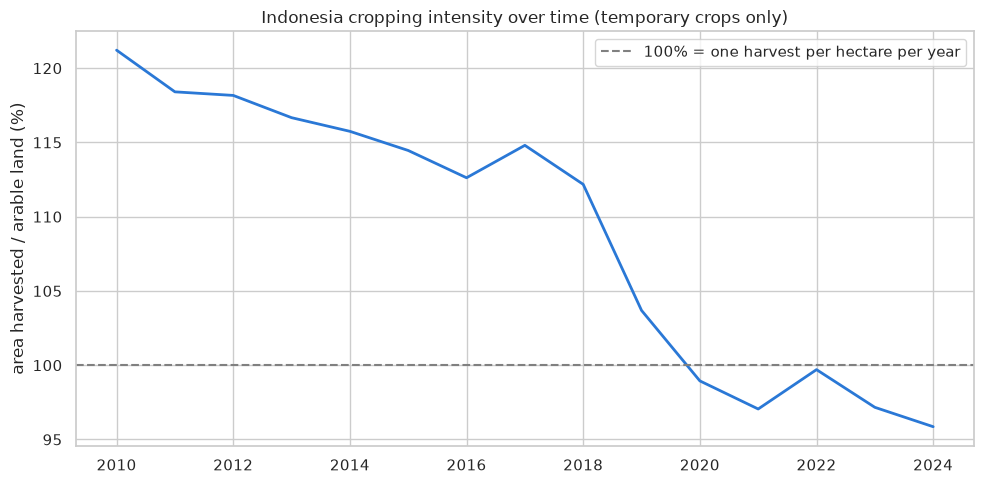

    year  area_harvested_ha  arable_land_1000ha  cropping_intensity_pct
5   2015         20419785.0            17840.57              114.457021
6   2016         20082717.0            17832.20              112.620524
7   2017         20462403.0            17823.83              114.803625
8   2018         19984886.0            17815.46              112.177210
9   2019         18464051.0            17807.09              103.689323
10  2020         17610636.0            17798.72               98.943272
11  2021         17265738.0            17790.35               97.051143
12  2022         17728917.0            17781.98               99.701591
13  2023         17278573.0            17782.90               97.163978
14  2024         16960967.0            17693.66               95.859008


In [2]:
if land is not None:
    arable = land[(land['Item'] == 'Arable land') & (land['Element'] == 'Area')][['year', 'value']]
    arable = arable.rename(columns={'value': 'arable_land_1000ha'})

    ah = qcl[qcl['Element'] == 'Area harvested']
    ah = drop_item_aggregates(ah)      # exclude roll-up totals (double counting)
    ah = drop_permanent_crops(ah)      # exclude oil palm/coconut/etc. (not arable land)
    harvested = ah.groupby('year')['value'].sum().rename('area_harvested_ha').reset_index()

    intensity = harvested.merge(arable, on='year', how='inner')
    # Area harvested is in ha, Arable land is in 1000 ha -> convert to matching units.
    intensity['cropping_intensity_pct'] = (
        100 * intensity['area_harvested_ha'] / (intensity['arable_land_1000ha'] * 1000)
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(intensity['year'], intensity['cropping_intensity_pct'], color='#2a78d6', linewidth=2)
    ax.axhline(100, ls='--', c='grey', label='100% = one harvest per hectare per year')
    ax.set_title('Indonesia cropping intensity over time (temporary crops only)')
    ax.set_ylabel('area harvested / arable land (%)')
    ax.legend()
    fig.tight_layout()
    viz.save(fig, 'cropping_intensity_over_time')
    plt.show()
    print(intensity.tail(10))
else:
    print('Land Use data not available — see src/load.load_landuse_indonesia docstring.')

### What's driving the cropping-intensity decline?
Aggregate temporary-crop area harvested fell ~2015→2024 while arable land stayed flat — decompose that by item to find which crops actually shrank.

In [3]:
ah = qcl[qcl['Element'] == 'Area harvested']
ah = drop_item_aggregates(ah)
ah = drop_permanent_crops(ah)

piv = ah[ah['year'].isin([2015, 2024])].pivot_table(index='Item', columns='year', values='value', aggfunc='sum')
piv = piv.dropna(subset=[2015, 2024])
piv['abs_change'] = piv[2024] - piv[2015]
piv['pct_change'] = 100 * piv['abs_change'] / piv[2015]
piv = piv.sort_values('abs_change')

total_decline = piv[piv['abs_change'] < 0]['abs_change'].sum()
top10_decline = piv.head(10)
growth = piv[piv['abs_change'] > 0].sort_values('abs_change', ascending=False)

print('Top 10 crops by absolute area-harvested decline, 2015->2024 (ha):')
print(top10_decline[[2015, 2024, 'abs_change', 'pct_change']])
print()
print('Crops with meaningful growth over the same period (ha):')
print(growth[[2015, 2024, 'abs_change', 'pct_change']].head(10))

rice_decline = piv.loc['Rice', 'abs_change']
maize_decline = piv.loc['Maize (corn)', 'abs_change']
rice_share = 100 * rice_decline / total_decline
top2_share = 100 * (rice_decline + maize_decline) / total_decline

print()
print(f'FINDINGS:')
print(
    f'Aggregate temporary-crop area harvested fell by {-total_decline:,.0f} ha '
    f'(sum of all declining items) from 2015 to 2024. Rice alone accounts for '
    f'{-rice_decline:,.0f} ha of that ({rice_share:.1f}% of the total decline) -- '
    f'the single largest contributor, but NOT a majority driver on its own. '
    f'Maize (corn) is almost as large ({-maize_decline:,.0f} ha, '
    f'{100*maize_decline/total_decline:.1f}%): together Rice+Maize explain '
    f'{top2_share:.1f}% of the decline. The remainder comes mainly from Soya '
    f'beans, Cassava, Groundnuts, and Sweet potatoes (all -30% to -78% over the '
    f'period) -- a broad-based pullback across staple/secondary food crops, not '
    f'a rice-specific story. A few items grew (chillies, sugar cane, onions, '
    f'nutmeg) but not enough to offset the staple-crop losses. Note: the '
    f'permanent-crop exclusion list (src/clean.py PERMANENT_CROP_ITEMS) is a '
    f'heuristic and known non-exhaustive -- items like nutmeg, areca nuts, and '
    f'tea (also perennial) are not excluded, so they still appear here; this '
    f'does not change the Rice/Maize conclusion above.'
)

Top 10 crops by absolute area-harvested decline, 2015->2024 (ha):
year                                 2015        2024  abs_change  pct_change
Item                                                                         
Rice                           11389000.0  10046135.0  -1342865.0  -11.790895
Maize (corn)                    3787367.0   2548654.0  -1238713.0  -32.706442
Soya beans                       613885.0    133376.0   -480509.0  -78.273455
Cassava, fresh                   949916.0    553450.0   -396466.0  -41.736954
Groundnuts, excluding shelled    454063.0    185439.0   -268624.0  -59.160073
Sweet potatoes                   143125.0     68630.0    -74495.0  -52.048908
Beans, dry                       229475.0    162085.0    -67390.0  -29.367033
Fibre Crops, Fibre Equivalent    180317.0    162109.0    -18208.0  -10.097772
Tea leaves                       114891.0    103605.0    -11286.0   -9.823224
Kapok fruit                      167902.0    156969.0    -10933.0   -6.51153

## Rice specifically — is multi-cropping visible?
Rice area harvested well above rice-suitable arable land area would itself suggest 2+ seasons/year, independent of the aggregate ratio above.

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_rice_area_harvested_over_time.png


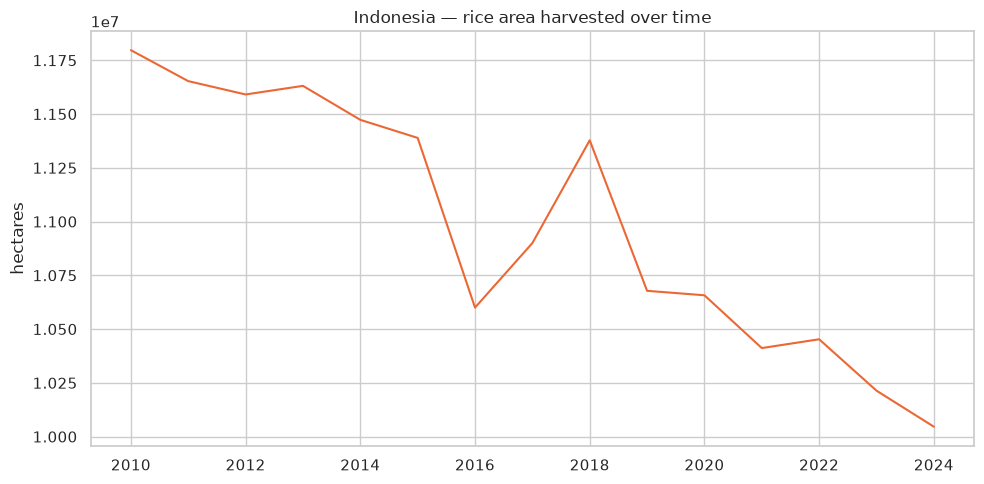

In [4]:
rice_area = qcl[(qcl['Item'] == 'Rice') & (qcl['Element'] == 'Area harvested')][['year', 'value']]
rice_area = rice_area.rename(columns={'value': 'rice_area_harvested'})
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rice_area['year'], rice_area['rice_area_harvested'], color='#eb6834')
ax.set_title('Indonesia — rice area harvested over time')
ax.set_ylabel('hectares')
fig.tight_layout()
viz.save(fig, 'idn_rice_area_harvested_over_time')
plt.show()

## Reference: published crop calendars (not from this repo's data)

**Important distinction from everything above:** the cropping-intensity chart was computed from the FAOSTAT data loaded in this notebook. The table and chart below are **not** — they're a reference compiled from published agronomy/trade sources (FAO GIEWS country reports, USDA FAS reports, peer-reviewed cropping-calendar studies), because FAOSTAT itself has no month-level data and Indonesia isn't covered by FAO's own Crop Calendar tool (checked directly — that tool covers ~58 countries, mostly Africa/Central Asia/Latin America; Indonesia isn't among them).

Treat this as a rough, regionally-variable orientation, not a precise per-province calendar — real timing shifts with rainfall, irrigation, and elevation.

| Crop | Planting | Harvest | Source |
|---|---|---|---|
| Rice — wet-season crop | Oct–Dec | Feb–Apr | [VOI](https://voi.id/en/economy/415574), [FAO GIEWS](https://www.fao.org/4/y6611E/pays/ins0204e.htm) |
| Rice — dry-season crop(s) | Apr–May | Jul–Aug | up to 2 dry-season crops/yr on irrigated land, same sources |
| Maize — rainy-season crop | Oct–Nov | Jan–Feb | [ResearchGate](https://www.researchgate.net/publication/242469500_Maize_in_Indonesia_Production_Systems_Constraints_and_Research_Priorities), [USDA FAS](https://www.fas.usda.gov/data/indonesia-grain-and-feed-update-3) |
| Maize — dry-season crop (after rice) | Mar–Apr | Jul | same sources |
| Cassava | ~Oct–Dec (start of wet season) | ~8–12 months later | [FAO](https://www.fao.org/4/x5032e/x5032e01.htm) — lower confidence, no exact months sourced |
| Sugar cane | perennial (ratoon) | May–Oct milling/crushing season, Java | [USDA FAS Sugar Annual](https://www.fas.usda.gov/data/indonesia-sugar-annual) |
| Oil palm | perennial | **year-round** — no season, ripe fresh-fruit-bunches harvested continuously | [Musim Mas](https://www.musimmas.com/resources/blogs/what-is-palm-oil-from-seed-to-harvest/) |
| Cocoa | perennial | main: Feb–May (end of wet season into early dry); secondary: Aug–Sep | [Indonesia Investments](https://www.indonesia-investments.com/business/commodities/cocoa/item241) |
| Coffee — Robusta (Java) | perennial | May–Aug | [Willkin Green Coffee](https://greencoffee.willkinsales.com/indonesia-coffee-harvest-season/) |
| Coffee — Arabica (N. Sumatra) | perennial | Mar–May and Oct–Dec (twice yearly) | same source |


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_crop_harvest_calendar_reference.png


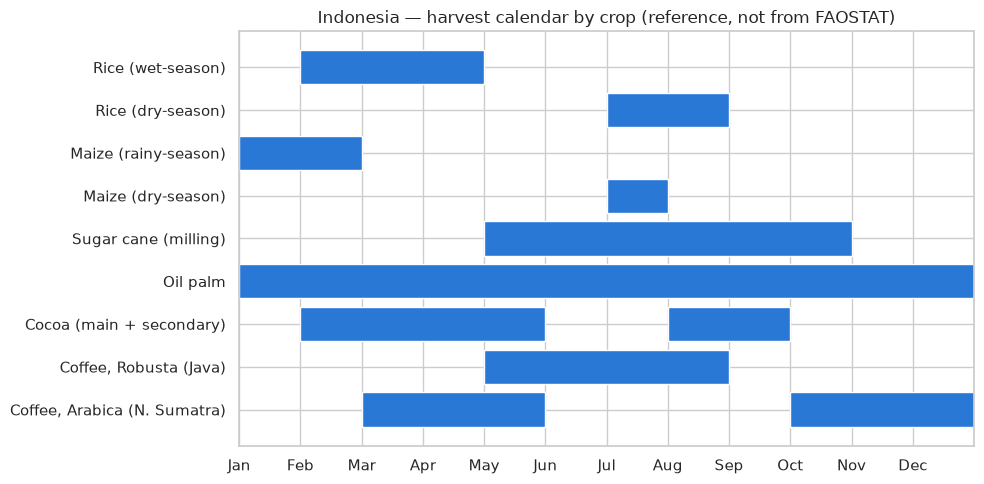

In [5]:
# Harvest-window reference chart (external knowledge — see table above, not FAOSTAT-derived).
# Perennial crops (oil palm, cocoa, coffee) have no annual planting event, so this shows
# HARVEST windows only — the one thing comparable across both annual and perennial crops.
harvest_windows = {
    'Rice (wet-season)':      [(2, 4)],
    'Rice (dry-season)':      [(7, 8)],
    'Maize (rainy-season)':   [(1, 2)],
    'Maize (dry-season)':     [(7, 7)],
    'Sugar cane (milling)':   [(5, 10)],
    'Oil palm':               [(1, 12)],
    'Cocoa (main + secondary)': [(2, 5), (8, 9)],
    'Coffee, Robusta (Java)': [(5, 8)],
    'Coffee, Arabica (N. Sumatra)': [(3, 5), (10, 12)],
}

def month_span_segments(start_month, end_month):
    """(start,end) 1-12 inclusive -> broken_barh (x0, width) segments, handling Dec->Jan wrap."""
    if start_month <= end_month:
        return [(start_month - 1, end_month - start_month + 1)]
    return [(start_month - 1, 12 - (start_month - 1)), (0, end_month)]

fig, ax = plt.subplots(figsize=(10, 5))
labels = list(harvest_windows.keys())
for row, label in enumerate(labels):
    segments = [seg for span in harvest_windows[label] for seg in month_span_segments(*span)]
    ax.broken_barh(segments, (row - 0.4, 0.8), facecolors='#2a78d6')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlim(0, 12)
ax.set_xticks(range(13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec',''])
ax.set_title('Indonesia — harvest calendar by crop (reference, not from FAOSTAT)')
ax.invert_yaxis()
fig.tight_layout()
viz.save(fig, 'idn_crop_harvest_calendar_reference')
plt.show()

## Summary

- **Cropping intensity:** … (fill in after running — is it rising, and is it above 100%, consistent with multi-season rice cultivation?)
- **What this notebook can't tell you:** which months planting/harvest happen in, or how that varies by island/province. That needs FAO's Crop Calendar data (see gap note above) — flag this as a follow-up download if the "when" angle becomes the project focus.
- Next: `04_synthesis` — pull the what/when findings together.